# 🌊 Wave Buoy Data from the U.S. National Data Buoy Center (NDBC)

Data is retrieved from the **National Data Buoy Center (NDBC)**:  
🔗 [https://www.ndbc.noaa.gov/](https://www.ndbc.noaa.gov/)

This notebook downloads and visualizes historical wave buoy data, including:

- **Bulk wave parameters**
- **Density energy spectra** (when available)
- **Directional wave spectra** (when available)

📘 **Reference documentation:**
- [NDBC Web Data Guide](https://www.ndbc.noaa.gov/docs/ndbc_web_data_guide.pdf)  
- [Measurement Descriptions & Units](https://www.ndbc.noaa.gov/faq/measdes.shtml)


---


<summary><strong>📥 Downloading Bulk Wave Parameters</strong></summary>

This section downloads time series data (e.g., significant wave height, period, direction) for a given buoy.

- NDBC data files are organized by year.
- File formats and available variables vary across years.
- This script handles inconsistencies and outputs a clean, standardized dataset.

---


<summary><strong>🌊 Downloading Density Energy Spectra</strong></summary>

This section retrieves **density energy spectra** data, stored in yearly files.

- Formats vary (e.g., frequency resolution, date formatting).
- The script processes each year independently but allows plotting across multiple years.
- Only buoys with a `"w"` suffix provide wave spectra. If data is unavailable, an HTTP 404 is raised and skipped.

📘 **More info:** [Wave Spectra Description](https://www.ndbc.noaa.gov/faq/wavespectra.shtml)



---


<summary><strong>🧭 Directional Wave Spectrum Reconstruction</strong></summary>

To reconstruct the directional wave spectrum, multiple coefficient files must be downloaded.

The directional spectrum is:

\[
\begin{align*}
S(f, A) = C_{11}(f) \cdot D(f, A)
\end{align*}
\]

Where:

- \( f \) = frequency (Hz)  
- \( A \) = azimuth angle (°), measured clockwise from true North (direction **waves come from**)  
- \( D(f, A) \) is defined as:

\[
\begin{align*}
D(f, A) = \frac{1}{\pi} \left[ 0.5 + R_1 \cos(A - \alpha_1) + R_2 \cos\left(2(A - \alpha_2)\right) \right]
\end{align*}
\]

### Fourier Coefficients

\[
\begin{align*}
R_1 &= \frac{\sqrt{a_1^2 + b_1^2}}{a_0} \\
R_2 &= \frac{\sqrt{a_2^2 + b_2^2}}{a_0} \\
\alpha_1 &= 270^\circ - \arctan2(b_1, a_1) \\
\alpha_2 &= 270^\circ - 0.5 \cdot \arctan2(b_2, a_2) \pm 180^\circ
\end{align*}
\]

### Notes

- Historical monthly/yearly `R1` and `R2` values are scaled by 100 → multiply by **0.01**
- \( D(f, A) \) may contain **negative values** due to cosine terms.
  - See: *Earle et al., Ocean Engineering (1999)* for methods to handle this
- \( \alpha_2 \) may be adjusted by 180° to minimize its difference with \( \alpha_1 \)

📘 **Further Reading:**  
Earle, Steele & Wang (1999). *Use of advanced directional wave spectra analysis methods*. Ocean Engineering, 26(12), 1421–1434.




Buoy 41025: No data available for year 1979
Buoy 41025: No data available for year 1980
Buoy 41025: No data available for year 1981
Buoy 41025: No data available for year 1982
Buoy 41025: No data available for year 1983
Buoy 41025: No data available for year 1984
Buoy 41025: No data available for year 1985
Buoy 41025: No data available for year 1986
Buoy 41025: No data available for year 1987
Buoy 41025: No data available for year 1988
Buoy 41025: No data available for year 1989
Buoy 41025: No data available for year 1990
Buoy 41025: No data available for year 1991
Buoy 41025: No data available for year 1992
Buoy 41025: No data available for year 1993
Buoy 41025: No data available for year 1994
Buoy 41025: No data available for year 1995
Buoy 41025: No data available for year 1996
Buoy 41025: No data available for year 1997
Buoy 41025: No data available for year 1998
Buoy 41025: No data available for year 1999
Buoy 41025: No data available for year 2000
Buoy 41025: No data available fo

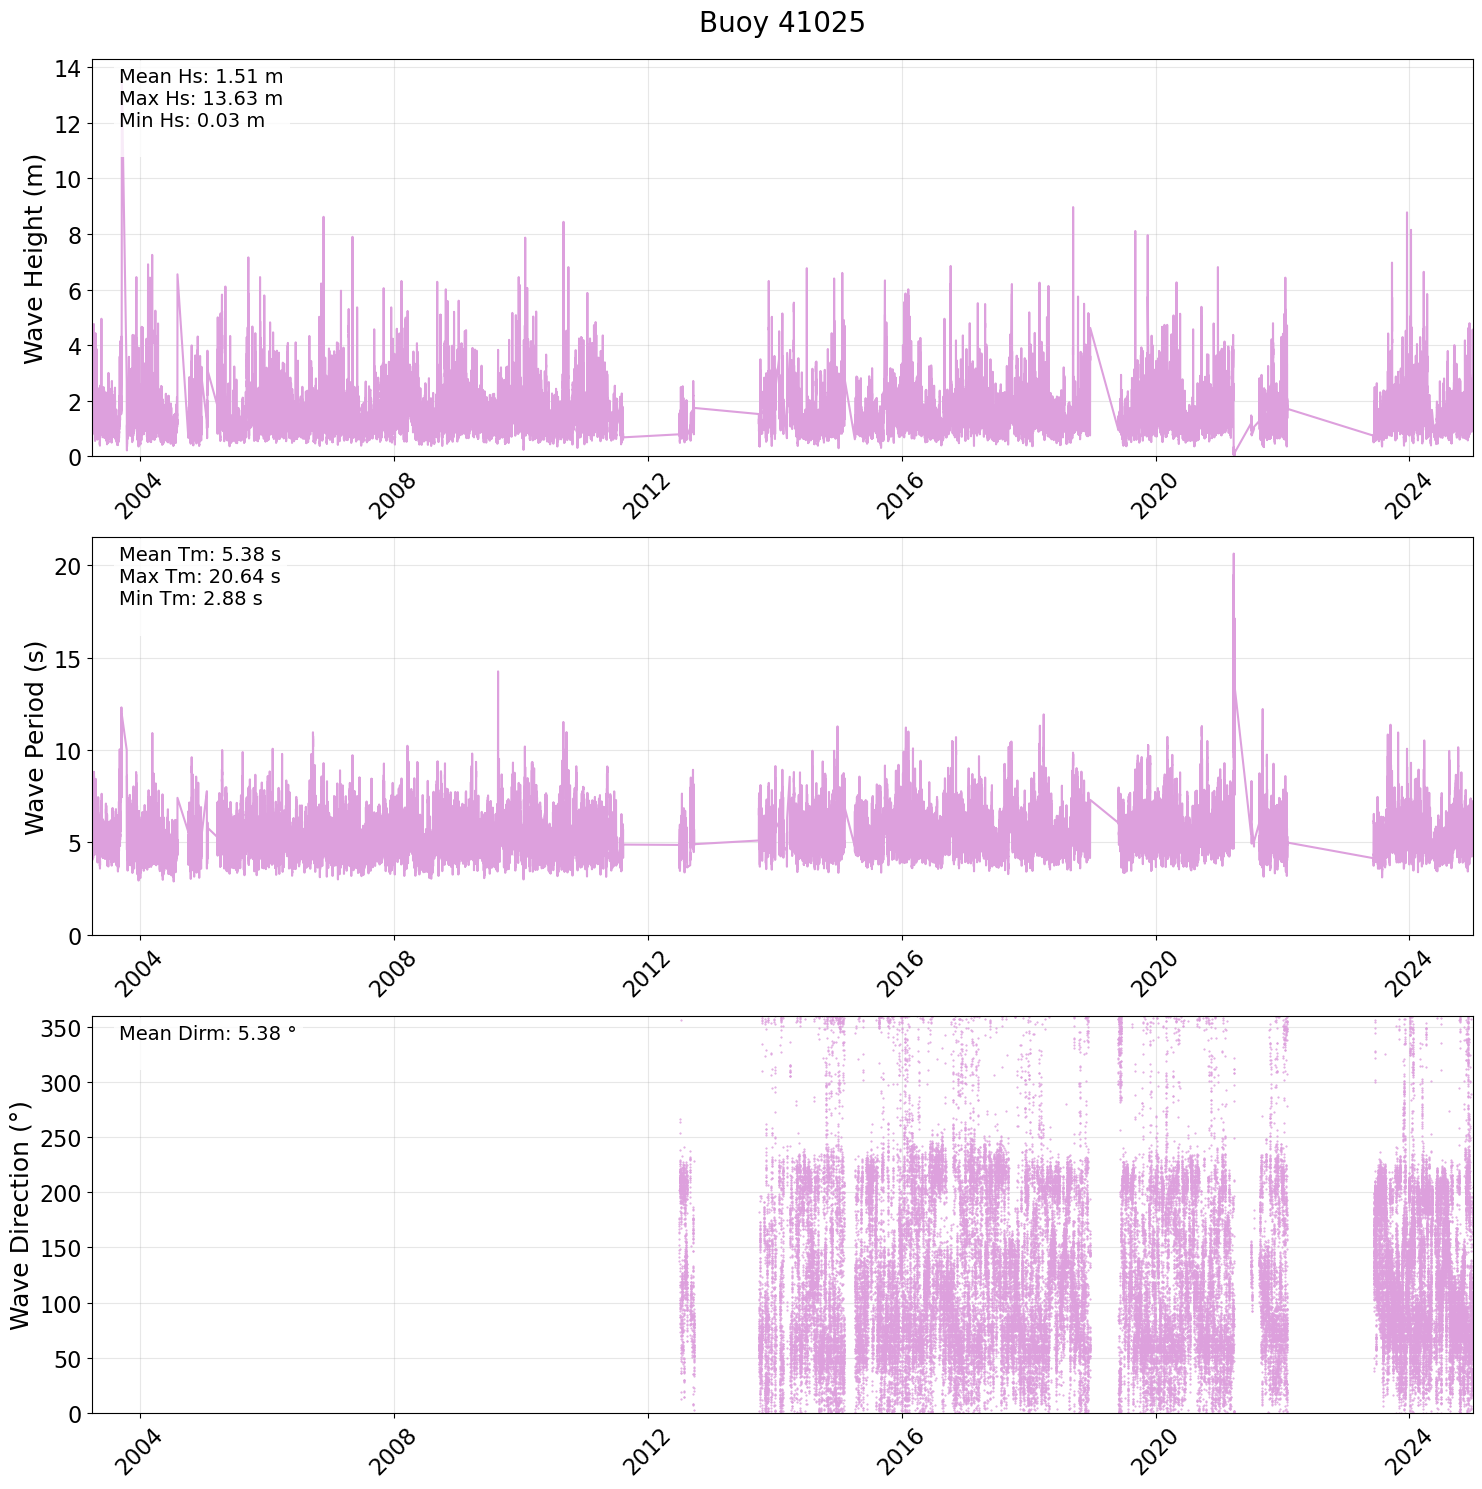

In [1]:
# Downloading and plotting Buoy Bulk parameters time-series
# Outputs:
# All outputs are saved in an auto-generated folder named buoy_id, with figures located in buoy_id/Figures.
# buoy_id_bulk_parameters.csv: Time-series of the downloaded bulk parameters.
# buoy_id_wave_parameters.png: Plot of the bulk parameters time-series.

%matplotlib inline
from utils.NDBC_download import process_buoy
from utils.NDBC_plot import plot_bulk_timeseries

buoy_ids = ['41025']

for buoy_id in buoy_ids:
    process_buoy(buoy_id, start_year=1979, end_year=2024,base_dir='./data/buoy_data')
    plot_bulk_timeseries(buoy_id,base_dir='./data/buoy_data')

In [2]:
#Convert to pkl to match BinWaves format

import sys
import os
from pathlib import Path

# Add the path to your utils directory if it's not already in your Python path
sys.path.append('/lustre/geocean/WORK/users/jen/BlueMath/methods/data_acquisition/utils')

# Import the function
from NDBC_download import convert_to_pickle

# Define the base path for data
base_path = '/lustre/geocean/WORK/users/jen/BlueMath/methods/data_acquisition/data/buoy_data'

# List of buoy numbers to process
buoy_numbers = ['41025'] 
# buoy_numbers = ['44056', '44088','41025','44086','44095','41120']  # Add more buoy numbers as needed

# Process each buoy
for buoy_number in buoy_numbers:
    # Create paths for this buoy
    buoy_dir = f'{base_path}/{buoy_number}'
    input_file = f'{buoy_dir}/buoy_{buoy_number}_bulk_parameters.csv'
    output_file = f'{buoy_dir}/buoy_{buoy_number}_bulk_parameters.pkl'
    
    print(f"Processing buoy {buoy_number}...")
    try:
        # Convert the CSV to pickle
        convert_to_pickle(input_file, output_file)
        print(f"Successfully processed buoy {buoy_number}")
    except Exception as e:
        print(f"Error processing buoy {buoy_number}: {str(e)}")

print("All buoys processed!")

# # Use the function for buoy 44088
# input_file = '/lustre/geocean/WORK/users/jen/BlueMath/methods/data_acquisition/data/buoy_data/44056/buoy_44056_bulk_parameters.csv'
# output_file = '/lustre/geocean/WORK/users/jen/BlueMath/methods/data_acquisition/data/buoy_data/44056/buoy_44056_bulk_parameters.pkl'

# # Convert the CSV to pickle
# convert_to_pickle(input_file, output_file)



Processing buoy 41025...
Processing file: /lustre/geocean/WORK/users/jen/BlueMath/methods/data_acquisition/data/buoy_data/41025/buoy_41025_bulk_parameters.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436959 entries, 0 to 436958
Data columns (total 18 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   YYYY    436959 non-null  int64  
 1   MM      436959 non-null  int64  
 2   DD      436959 non-null  int64  
 3   hh      436959 non-null  int64  
 4   mm      436959 non-null  int64  
 5   WD      436959 non-null  int64  
 6   WSPD    436959 non-null  float64
 7   GST     436959 non-null  float64
 8   WVHT    155555 non-null  float64
 9   DPD     155420 non-null  float64
 10  APD     155556 non-null  float64
 11  MWD     87372 non-null   float64
 12  BAR     436959 non-null  float64
 13  ATMP    436959 non-null  float64
 14  WTMP    436959 non-null  float64
 15  DEWP    436959 non-null  float64
 16  VIS     436959 non-null  float64
 17  TID

In [ ]:
# Downloading and plotting Buoy Wave Energy Spectra
# Outputs:
# Generates a folder  (buoy_id/ wave_spectra) with files containing the wave energy spectra for each year.
# Figures are saved in buoy_id/Figures:
# monthly_spectra_buoy_id_start_year_end_year.png: Monthly averaged wave spectra for the specified time range. The figure shows(Light lines: Monthly averages for each individual year,Dark line: Overall average for each month across all years)
# seasonal_spectra_buoy_id_start_year_end_year.png: Seasonal averaged spectra.  The figure shows(Light lines: Seasonal averages for each individual year,Dark line: Overall average for each season across all years)
# Average_spectra_buoy_id_start_year_end_year.png: averaged spectra for the specified time range, with the yearly average and total average.
%matplotlib inline
from utils.NDBC_download import download_wave_spectra
from utils.NDBC_plot import plot_yearly_averages
from utils.NDBC_plot import plot_seasonal_averages
from utils.NDBC_plot import plot_monthly_averages
buoy_ids = ['41013']
for buoy_id in buoy_ids:
    download_wave_spectra(buoy_id, start_year=2000,base_dir='./data/buoy_data')
    plot_yearly_averages(buoy_id, base_dir='./data/buoy_data',start_year=2000)
    plot_seasonal_averages(buoy_id, base_dir='./data/buoy_data', start_year=2000, end_year=None)
    plot_monthly_averages(buoy_id, base_dir='./data/buoy_data', start_year=2000, end_year=None)


In [ ]:
# Downloading Directional Wave Spectra files
# Outputs:
# Creates a folder buoy_id/directional_spectra containing the downloaded file per coefficient (alpha1, alpha2, r1, r2, c11) per year, required for spectral reconstruction.

from utils.NDBC_download import download_directional_spectra
buoy_ids = ['41013']
for buoy_id in buoy_ids:
    download_directional_spectra(buoy_id, start_year=2014, end_year=2018, base_dir='./data/buoy_data')

In [ ]:
# Figures are saved in buoy_id/Figures:
# seasonal_directional_spectra_start_dt_end_dt.png: Seasonal directional spectra averagefor the specified time range.
# monthly_directional_spectra_start_dt_end_dt.png: Monthly directional spectra average for the specified time range.
# average_directional_spectrum_start_dt_end_dt.png: Average directional spectrum for the specified time range.

from utils.NDBC_download import read_specific_date_data, read_and_process_data
from utils.NDBC_plot import plot_specific_date_directional_spectrum, plot_average_directional_spectrum, plot_seasonal_directional_spectra, plot_monthly_directional_spectra

# Example usage
buoy_id = "41013"
date_str = "2015-06-01 12:00"  # For specific date plot
start_date = "2014-01-01 00:00"  # For seasonal/monthly/average plots
end_date = "2018-12-31 23:59"    # For seasonal/monthly/average plots
base_dir='./data/buoy_data'

# For specific date plot
data = read_specific_date_data(buoy_id, date_str, base_dir)
if data is not None:
    alpha1, alpha2, r1, r2, c11, freqs = data
    # Plot specific date
    plot_specific_date_directional_spectrum(alpha1, alpha2, r1, r2, c11, freqs, 
                                          buoy_id, date_str, base_dir)

# For seasonal/monthly/annual plots
annual_data = read_and_process_data(buoy_id, start_date, end_date, base_dir)
if annual_data is not None:
    alpha1_df, alpha2_df, r1_df, r2_df, c11_df = annual_data
    # Plot seasonal, monthly, and annual data
    plot_seasonal_directional_spectra(alpha1_df, alpha2_df, r1_df, r2_df, c11_df,
                                    buoy_id, start_date, end_date, base_dir)
    plot_monthly_directional_spectra(alpha1_df, alpha2_df, r1_df, r2_df, c11_df,
                                   buoy_id, start_date, end_date, base_dir)
    plot_average_directional_spectrum(alpha1_df, alpha2_df, r1_df, r2_df, c11_df,
                                   buoy_id, start_date, end_date, base_dir)